In [ ]:
%%capture

!pip install torch torchvision torchaudio
!pip install transformers accelerate
!pip install albumentations opencv-python pillow pandas scikit-learn tqdm


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import SegformerConfig, SegformerForSemanticSegmentation
import os
import zipfile
import random
import json
from pathlib import Path
from tqdm import tqdm


> Seeding

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

## Import Dataset

- Unzip dataset

In [ ]:
file_id = '114xnPVZtthHi4Bejzho33vGJSqb4-F8g'
output_zip = '/content/dataset.zip'
extract_path = '/content/flopwd_data'

In [ ]:
!gdown --id {file_id} -O {output_zip}

if os.path.exists(output_zip):
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(output_zip, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Success! Dataset extracted to {extract_path}")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=114xnPVZtthHi4Bejzho33vGJSqb4-F8g
From (redirected): https://drive.google.com/uc?id=114xnPVZtthHi4Bejzho33vGJSqb4-F8g&confirm=t&uuid=632275bb-540f-401a-98a1-f77429c1828f
To: /content/dataset.zip
100% 358M/358M [00:03<00:00, 119MB/s]
Success! Dataset extracted to /content/flopwd_data


- Get Images

In [ ]:
raw_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images").glob("*")))
mask_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks").glob("*")))
labels_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Image_labels_Binary Classification Task.csv")
reg_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Mask_foreground_percentages_Regression Task.csv")

In [ ]:
labels_df = pd.read_csv(labels_csv)
reg_df = pd.read_csv(reg_csv)

In [ ]:
labels_df.head()

,image name,Presence of plastic waste?
0,img1.jpg,yes
1,img2.jpg,yes
2,img3.jpg,yes
3,img4.jpg,yes
4,img5.jpg,yes


In [ ]:
reg_df.head()

,image name,plastic waste accumulation (in percentage)
0,img1.jpg,0.08
1,img2.jpg,0.03
2,img3.jpg,0.38
3,img4.jpg,0.20
4,img5.jpg,0.18


### Transform Dataset

In [ ]:
labels_df = labels_df.rename(columns={
    "image name": "image_name",
    "Presence of plastic waste?": "presence"
})

reg_df = reg_df.rename(columns={
    "image name": "image_name",
    "plastic waste accumulation (in percentage)": "fg_pct"
})

df = labels_df.merge(reg_df, on="image_name", how="inner")

df["image_path"] = df["image_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images") / x))
df["mask_name"] = df["image_name"].str.replace(".jpg", "_mask.png", regex=False)
df["mask_path"] = df["mask_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks") / x))

df["presence"] = df["presence"].astype(str).str.strip().str.lower()
df["has_plastic"] = (df["presence"] == "yes").astype(int)

df.head()

,image_name,presence,fg_pct,image_path,mask_name,mask_path,has_plastic
0,img1.jpg,yes,0.08,/content/flopwd_data/Dal Lake Floating Plastic...,img1_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
1,img2.jpg,yes,0.03,/content/flopwd_data/Dal Lake Floating Plastic...,img2_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
2,img3.jpg,yes,0.38,/content/flopwd_data/Dal Lake Floating Plastic...,img3_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
3,img4.jpg,yes,0.20,/content/flopwd_data/Dal Lake Floating Plastic...,img4_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
4,img5.jpg,yes,0.18,/content/flopwd_data/Dal Lake Floating Plastic...,img5_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1


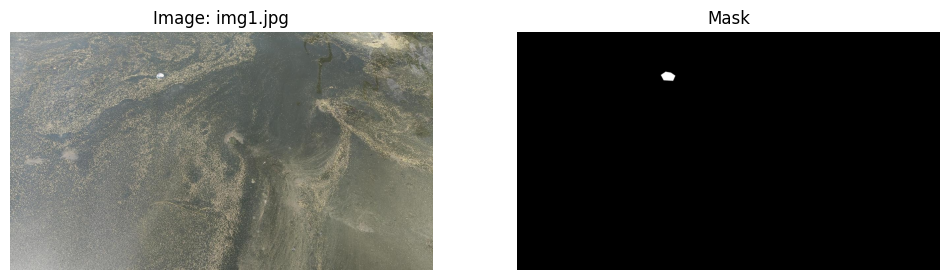

In [ ]:
row = df.iloc[0]
image = cv2.imread(row["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Image: {row['image_name']}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

## Data Splitting (70:15:15)

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["has_plastic"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.17647,
    random_state=42,
    stratify=train_df["has_plastic"]
)

In [ ]:
# reset
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 1400
Val  : 301
Test : 301


## Data Preprocessing

### Image Augmentation

In [ ]:
IMAGE_HEIGHT = 512
IMAGE_WIDTH = 512
BATCH_SIZE = 4
NUM_CLASSES = 2
SEGFORMER_MODEL = "nvidia/mit-b3"


In [ ]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

In [ ]:
# transform only training and validation images

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.OneOf([
        A.ElasticTransform(alpha=1, sigma=50, p=0.5),
        A.GridDistortion(p=0.5),
    ], p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),
    A.CoarseDropout(
        num_holes_range=(1, 8),
        hole_height_range=(16, 32),
        hole_width_range=(16, 32),
        p=0.3
    ),
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Image Preprocessing (Class & Dataloader)

In [ ]:
class FloPWDDataset(Dataset):
  def __init__(self, dataframe, transforms=None):
    self.dataframe = dataframe
    self.transforms = transforms

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    row = self.dataframe.iloc[idx]

    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.uint8)  # 0 = background, 1 = plastic

    if self.transforms:
      transformed = self.transforms(image=image, mask=mask)
      image = transformed["image"]
      mask = transformed["mask"]

    # SegFormer + CrossEntropyLoss expects target shape [H, W] with dtype long.
    mask = mask.long()

    return image, mask


In [ ]:
train_dataset = FloPWDDataset(train_df, transforms=train_transform)
val_dataset = FloPWDDataset(val_df, transforms=val_transform)
test_dataset = FloPWDDataset(test_df, transforms=val_transform)


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


## Modelling

In [ ]:
config = SegformerConfig(
    num_labels=NUM_CLASSES
)

model = SegformerForSemanticSegmentation(config)


## Training

#### Training Hyperparameter

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEVICE

'cuda'

In [ ]:
model = model.to(DEVICE)

#### Loss Function

##### Pos Weight Estimation for Class Imbalance Handlign

For Give more loss if positive pixel are predicted falsely (FP)

In [ ]:
pos_pixels = 0
neg_pixels = 0

# step 1: sampling sebanyak 200
subset = train_df.sample(min(200, len(train_df)), random_state=42)

for _, row in subset.iterrows():
  mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
  mask = (mask > 127).astype(np.uint8)

  pos_pixels += mask.sum()
  neg_pixels += mask.size - mask.sum()

pos_weight = neg_pixels / max(pos_pixels, 1)

pos_weight

np.float64(18.368890673898054)

##### BCE

Loss function for Clasification per pixel

In [ ]:
# CrossEntropyLoss untuk SegFormer multi-class logits: [B, C, H, W].
# Class 0 = background, class 1 = plastic.
class_weights = torch.tensor([1.0, float(min(pos_weight, 50.0))], device=DEVICE)
ce_loss = nn.CrossEntropyLoss(weight=class_weights)

class_weights

tensor([ 1.0000, 18.3689], device='cuda:0')

##### DICE

Loss function for Mask Overlapping

In [ ]:
def dice_loss(logits, targets, smooth=1.0):
  probs = torch.softmax(logits, dim=1)[:, 1, :, :]
  targets = targets.float()

  intersection = (probs * targets).sum(dim=(1, 2))
  union = probs.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))

  dice = (2.0 * intersection + smooth) / (union + smooth)
  return 1.0 - dice.mean()


#####  Combine

In [ ]:
def combined_loss(logits, targets, dice_weight=0.7, ce_weight=0.3):
  d_loss = dice_loss(logits, targets)
  c_loss = ce_loss(logits, targets)
  return dice_weight * d_loss + ce_weight * c_loss


#### Optimizer

In [ ]:
encoder_params = list(model.segformer.parameters())
decoder_params = list(model.decode_head.parameters())

optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": 1e-5},
    {"params": decoder_params, "lr": 3e-4},
], weight_decay=1e-4)

scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))


#### Metric

In [ ]:
def apply_sigmoid(x):
  return torch.sigmoid(x)

In [ ]:
def segformer_forward(model, images, target_size):
  outputs = model(pixel_values=images)
  logits = outputs.logits

  logits = F.interpolate(
      logits,
      size=target_size,
      mode="bilinear",
      align_corners=False
  )
  return logits


def binarize_mask(prob_mask, threshold=0.5):
  return (prob_mask > threshold).float()


In [ ]:
def compute_stats(preds, targets, eps=1e-7):
  preds = preds.float()
  targets = targets.float()

  tp = (preds * targets).sum(dim=(1, 2))
  fp = (preds * (1 - targets)).sum(dim=(1, 2))
  fn = ((1 - preds) * targets).sum(dim=(1, 2))

  tn = ((1 - preds) * (1 - targets)).sum(dim=(1, 2))

  foreground_iou = (tp + eps) / (tp + fp + fn + eps)
  background_iou = (tn + eps) / (tn + fp + fn + eps)
  miou = (foreground_iou + background_iou) / 2.0

  dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
  precision = (tp + eps) / (tp + fp + eps)
  recall = (tp + eps) / (tp + fn + eps)

  return {
      "iou": foreground_iou.mean().item(),
      "foreground_iou": foreground_iou.mean().item(),
      "background_iou": background_iou.mean().item(),
      "miou": miou.mean().item(),
      "dice": dice.mean().item(),
      "precision": precision.mean().item(),
      "recall": recall.mean().item()
  }


In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            logits = segformer_forward(model, images, target_size=(masks.shape[1], masks.shape[2]))
            loss = combined_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return running_loss / len(loader)


In [ ]:
def validate_one_epoch(model, loader, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    iou_scores = []
    foreground_iou_scores = []
    background_iou_scores = []
    miou_scores = []
    dice_scores = []
    precision_scores = []
    recall_scores = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = segformer_forward(model, images, target_size=(masks.shape[1], masks.shape[2]))
            loss = combined_loss(logits, masks)

            probs = torch.softmax(logits, dim=1)[:, 1, :, :]
            preds = binarize_mask(probs, threshold=threshold)

            stats = compute_stats(preds, masks)

            running_loss += loss.item()
            iou_scores.append(stats["iou"])
            foreground_iou_scores.append(stats["foreground_iou"])
            background_iou_scores.append(stats["background_iou"])
            miou_scores.append(stats["miou"])
            dice_scores.append(stats["dice"])
            precision_scores.append(stats["precision"])
            recall_scores.append(stats["recall"])

    return {
        "loss": running_loss / len(loader),
        "iou": np.mean(iou_scores),
        "foreground_iou": np.mean(foreground_iou_scores),
        "background_iou": np.mean(background_iou_scores),
        "miou": np.mean(miou_scores),
        "dice": np.mean(dice_scores),
        "precision": np.mean(precision_scores),
        "recall": np.mean(recall_scores)
    }


In [ ]:
def find_best_threshold(model, loader, device):
    thresholds = np.arange(0.10, 0.91, 0.05)
    best_threshold = 0.5
    best_dice = -1

    model.eval()

    all_probs = []
    all_masks = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Collecting val probs", leave=False):
            images = images.to(device)
            masks = masks.to(device)

            logits = segformer_forward(model, images, target_size=(masks.shape[1], masks.shape[2]))
            probs = torch.softmax(logits, dim=1)[:, 1, :, :].cpu()

            all_probs.append(probs)
            all_masks.append(masks.cpu().float())

    all_probs = torch.cat(all_probs, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    for threshold in thresholds:
        preds = (all_probs > threshold).float()
        stats = compute_stats(preds, all_masks)
        if stats["dice"] > best_dice:
            best_dice = stats["dice"]
            best_threshold = threshold

    return best_threshold, best_dice


#### Training

In [ ]:
EPOCHS = 30
PATIENCES = 5

In [ ]:
best_val_dice = -1
best_model_path = "/content/best_flopwd_segformer_b3_miou.pth"

history = []
counter = 0


In [ ]:
for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)

    best_threshold, _ = find_best_threshold(model, val_loader, DEVICE)
    val_metrics = validate_one_epoch(model, val_loader, DEVICE, threshold=best_threshold)

    print(f"Train Loss        : {train_loss:.4f}")
    print(f"Val Loss          : {val_metrics['loss']:.4f}")
    print(f"Val Foreground IoU: {val_metrics['foreground_iou']:.4f}")
    print(f"Val Background IoU: {val_metrics['background_iou']:.4f}")
    print(f"Val mIoU          : {val_metrics['miou']:.4f}")
    print(f"Val Dice          : {val_metrics['dice']:.4f}")
    print(f"Val Precision     : {val_metrics['precision']:.4f}")
    print(f"Val Recall        : {val_metrics['recall']:.4f}")
    print(f"Best Threshold    : {best_threshold:.2f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_iou": val_metrics["iou"],
        "val_foreground_iou": val_metrics["foreground_iou"],
        "val_background_iou": val_metrics["background_iou"],
        "val_miou": val_metrics["miou"],
        "val_dice": val_metrics["dice"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "best_threshold": float(best_threshold)
    })

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")
        counter = 0
    else:
        counter += 1
        print(f"No improvement. Patience counter: {counter}/{PATIENCES}")

    if counter >= PATIENCES:
        print("Early stopping triggered.")
        break



Epoch [1/30]


Train Loss        : 0.7948
Val Loss          : 0.7553
Val Foreground IoU: 0.2500
Val Background IoU: 0.9389
Val mIoU          : 0.5945
Val Dice          : 0.2500
Val Precision     : 0.9627
Val Recall        : 0.2566
Best Threshold    : 0.90
Best model saved.

Epoch [2/30]


Train Loss        : 0.7729
Val Loss          : 0.7480
Val Foreground IoU: 0.1343
Val Background IoU: 0.7637
Val mIoU          : 0.4490
Val Dice          : 0.1850
Val Precision     : 0.1563
Val Recall        : 0.7089
Best Threshold    : 0.60
No improvement. Patience counter: 1/5

Epoch [3/30]


Train Loss        : 0.7626
Val Loss          : 0.7523
Val Foreground IoU: 0.1255
Val Background IoU: 0.8029
Val mIoU          : 0.4642
Val Dice          : 0.1800
Val Precision     : 0.1571
Val Recall        : 0.6678
Best Threshold    : 0.70
No improvement. Patience counter: 2/5

Epoch [4/30]


Train Loss        : 0.7634
Val Loss          : 0.7491
Val Foreground IoU: 0.1331
Val Background IoU: 0.8555
Val mIoU          : 0.4943
Val Dice          : 0.1872
Val Precision     : 0.1765
Val Recall        : 0.5707
Best Threshold    : 0.75
No improvement. Patience counter: 3/5

Epoch [5/30]


Train Loss        : 0.7564
Val Loss          : 0.7371
Val Foreground IoU: 0.1428
Val Background IoU: 0.8772
Val mIoU          : 0.5100
Val Dice          : 0.2079
Val Precision     : 0.2135
Val Recall        : 0.5768
Best Threshold    : 0.75
No improvement. Patience counter: 4/5

Epoch [6/30]


Train Loss        : 0.7525
Val Loss          : 0.7338
Val Foreground IoU: 0.1718
Val Background IoU: 0.9061
Val mIoU          : 0.5389
Val Dice          : 0.2332
Val Precision     : 0.2917
Val Recall        : 0.4723
Best Threshold    : 0.80
No improvement. Patience counter: 5/5
Early stopping triggered.


##### Training History

In [ ]:
history_df = pd.DataFrame(history)
history_df.to_csv("/content/flopwd_training_history.csv", index=False)
history_df.tail()

,epoch,train_loss,val_loss,val_iou,val_foreground_iou,val_background_iou,val_miou,val_dice,val_precision,val_recall,best_threshold
1,2,0.772948,0.747974,0.134254,0.134254,0.763662,0.448958,0.184958,0.156256,0.708888,0.60
2,3,0.762630,0.752311,0.125487,0.125487,0.802877,0.464182,0.179994,0.157109,0.667756,0.70
3,4,0.763355,0.749061,0.133142,0.133142,0.855482,0.494312,0.187195,0.176484,0.570680,0.75
4,5,0.756414,0.737109,0.142830,0.142830,0.877243,0.510036,0.207872,0.213523,0.576831,0.75
5,6,0.752543,0.733819,0.171754,0.171754,0.906115,0.538934,0.233184,0.291706,0.472277,0.80


##### Best Model

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

<All keys matched successfully>

##### Best Threshold

In [ ]:
best_threshold, best_dice = find_best_threshold(model, val_loader, DEVICE)

#### Save Model

In [ ]:
from transformers import AutoImageProcessor

processor = AutoImageProcessor.from_pretrained(SEGFORMER_MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

The image processor of type `SegformerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [ ]:
model.save_pretrained("segformer-plastic")
processor.save_pretrained("segformer-plastic")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['segformer-plastic/preprocessor_config.json']

#### Evaluation

In [ ]:
test_metrics = validate_one_epoch(model, test_loader, DEVICE, threshold=best_threshold)

for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

loss: 0.7562
iou: 0.2401
foreground_iou: 0.2401
background_iou: 0.9467
miou: 0.5934
dice: 0.2401
precision: 0.9345
recall: 0.2599


- Result

In [ ]:
with open("/content/flopwd_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

## Inferences

In [ ]:
def denormalize_image(image_tensor, mean, std):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = image * np.array(std) + np.array(mean)
    image = np.clip(image, 0, 1)
    return image

def show_predictions(model, dataset, device, threshold=0.5, num_samples=5):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    plt.figure(figsize=(15, num_samples * 5))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]

            input_tensor = image.unsqueeze(0).to(device)
            logits = segformer_forward(model, input_tensor, target_size=(mask.shape[0], mask.shape[1]))
            probs = torch.softmax(logits, dim=1)[:, 1, :, :]
            pred = (probs > threshold).float()

            image_np = denormalize_image(image, mean, std)
            mask_np = mask.cpu().numpy()
            pred_np = pred.squeeze().cpu().numpy()

            plt.subplot(num_samples, 3, i * 3 + 1)
            plt.imshow(image_np)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 2)
            plt.imshow(mask_np, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 3)
            plt.imshow(pred_np, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


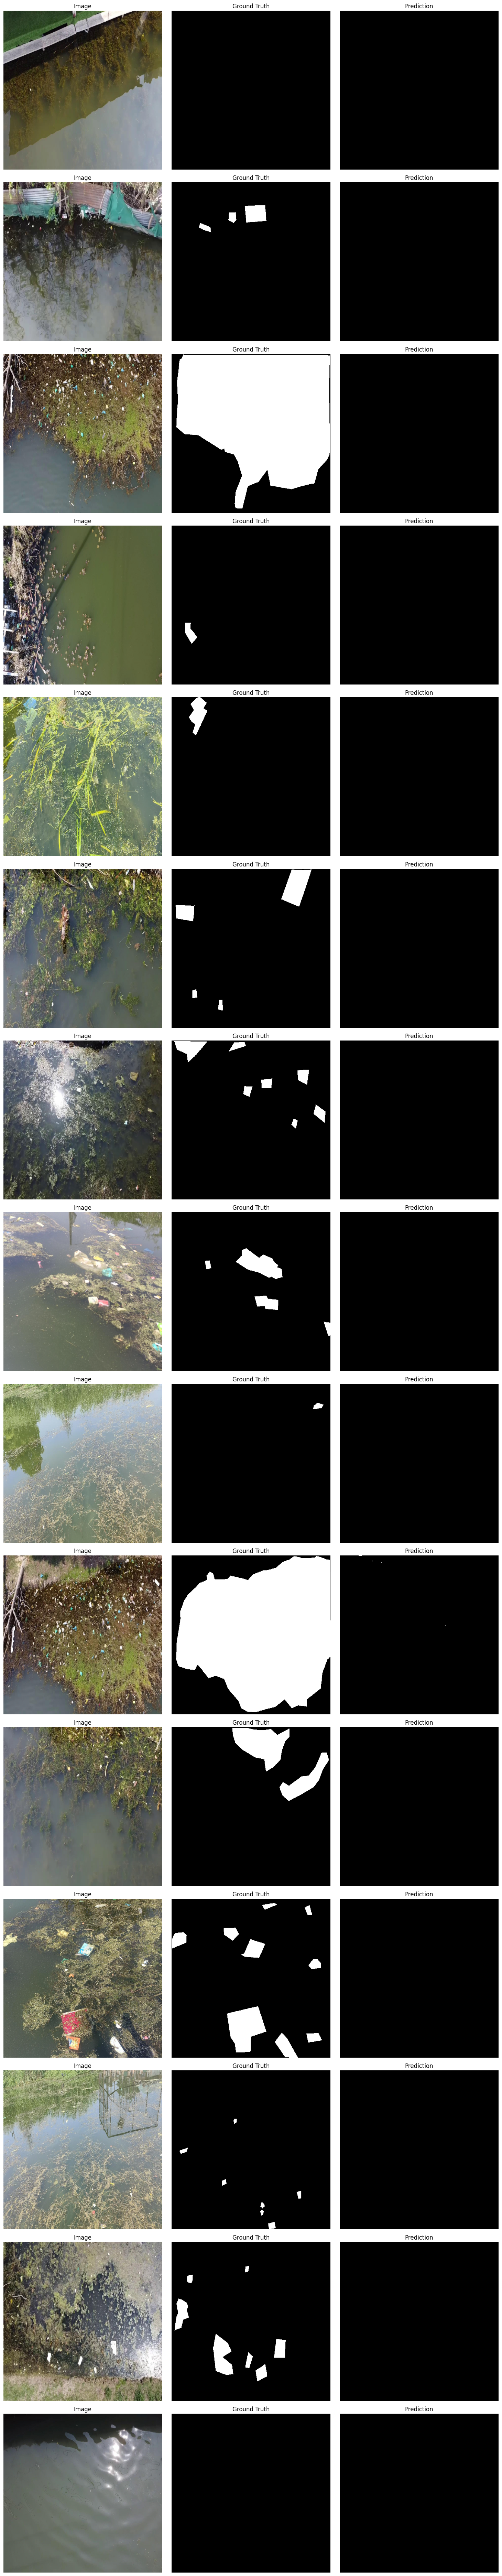

In [ ]:
show_predictions(model, test_dataset, DEVICE, threshold=best_threshold, num_samples=15)